# =============================================================================
# Jupyter Notebook about cluster methodology
# Aplication to Weather Regimes
# =============================================================================


## Tomamos los datos del ERA5 en MAM diariamente ( años multiplicados por 92 días)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from werim import (
    Dataset, Region, Month,
    Clim, Anom, 
    Preprocess,
    WeatherRegimes,
)

In [2]:
DATASETS_DIR = "/Users/Shared/datasets"

ds = Dataset("slp_daily_1940_2024_era5data1g.nc", folder=DATASETS_DIR).open()
ds.slice(Region(
    lat0=20, latf=64, lon0=-40, lonf=39,
    month0=Month.MAR, monthf=Month.MAY,
    year0=1940, yearf=2024,
))

INFO 2026-06-30 14:19:47: Detected variable msl from: msl


((<Figure size 800x600 with 2 Axes>,), ((<GeoAxes: >,),))

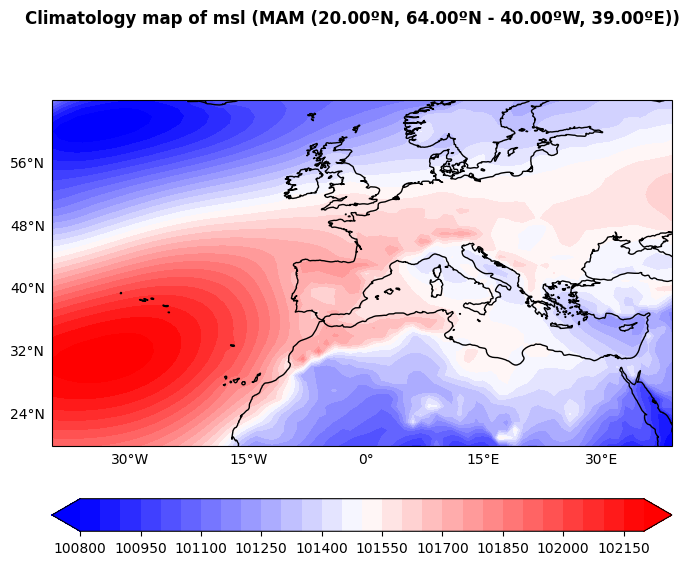

In [3]:
Clim(ds, "map").plot(cmap="bwr", levels=30, figsize=(8, 6))

((<Figure size 800x600 with 2 Axes>,), ((<GeoAxes: >,),))

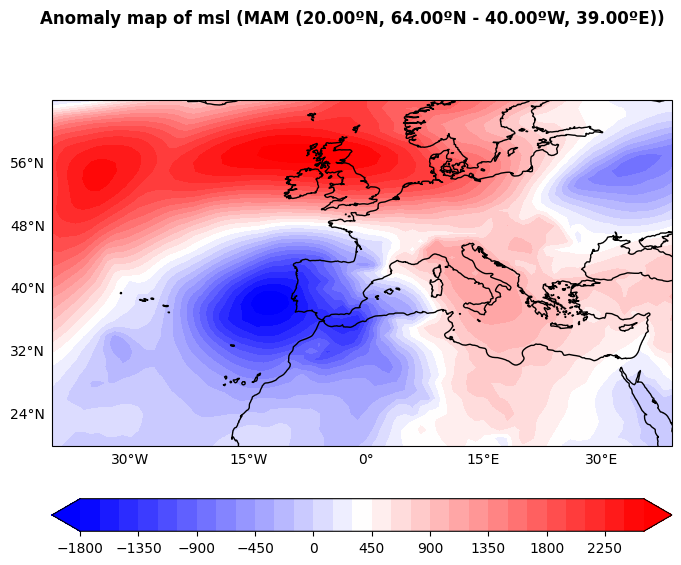

In [4]:
anom = Anom(ds, "map", group_season=False)
anom.plot(timestamp="1940-03-01", cmap="bwr", levels=30, figsize=(8, 6))

Finally, we reshape for having all times together

In [8]:
anom.data.shape #años,dias, lat,lon

(7820, 45, 80)

=============================================================================
# ANALISIS EOF
# =============================================================================
 Ahora vamos a calcular los principales modos de variabilidad del z600 anómalo. Para ello, primero eliminamos la tendencia y aplicamos la función EOF, definida anteriormente. La función tiene que ser aplicada a datos con dimensiones (ns, nt), así que transponemos, y reformamos para tener 2 dimensiones# 

In [9]:
nm = 10
alpha = 0.1
k = 4

In [10]:
pre = Preprocess(ds, detrend=True, group_season=False)
# pre.save("pre_", DATA_DIR)
# pre = Preprocess.load("pre_", DATA_DIR)

INFO 2026-06-30 14:21:13: Preprocessing data for variable msl:  took: 0.859 seconds: 



((<Figure size 800x600 with 2 Axes>,),
 ((<GeoAxes: title={'center': 'Date: 1940-03-01T00:00:00.000000000'}>,),))

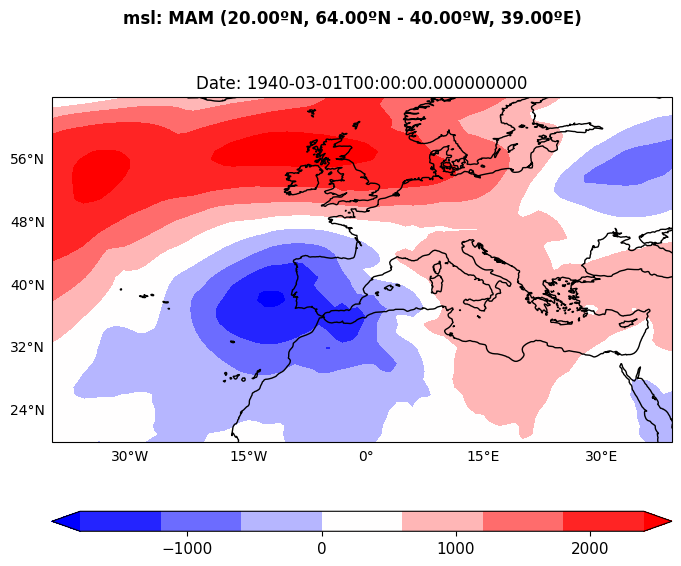

In [11]:
pre.plot(timestamp="1940-03-01", figsize=(8, 6))

In [12]:
wr = WeatherRegimes(pre, nm=nm, k=k, alpha=alpha)
# wr.save("wr_", DATA_DIR)
# wr = WeatherRegimes.load("wr_", DATA_DIR, ds=pre)

INFO 2026-06-30 14:21:15: Calculating Weather Regimes
    Shape:  (3600, 7820) 
    Region: MAM (20.00ºN, 64.00ºN - 40.00ºW, 39.00ºE)
:     Took: 8.517 seconds


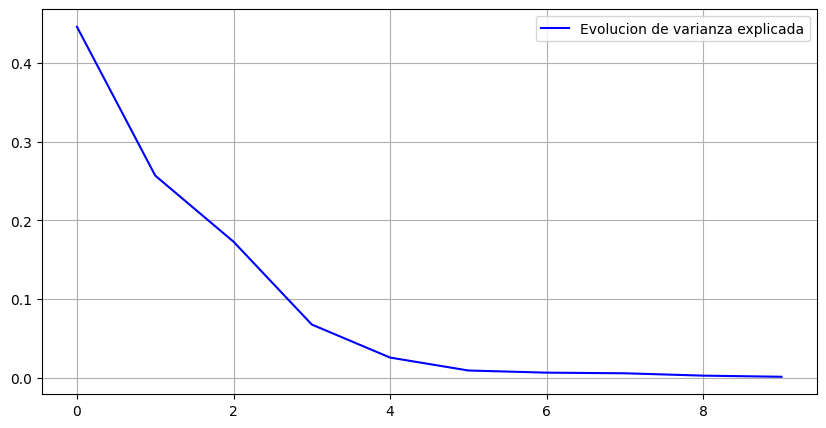

In [14]:
fig, ax = plt.subplots(figsize = (10,5))
plt.plot(wr.fvar[:10], color='Blue', label='Evolucion de varianza explicada')
plt.legend()
plt.grid()

((<Figure size 1700x710.127 with 11 Axes>,),
 ((<GeoAxes: title={'center': 'msl mode 1. fvar=44.6%'}>,
   <GeoAxes: title={'center': 'msl mode 2. fvar=25.7%'}>,
   <GeoAxes: title={'center': 'msl mode 3. fvar=17.3%'}>,
   <GeoAxes: title={'center': 'msl mode 4. fvar=6.8%'}>,
   <GeoAxes: title={'center': 'msl mode 5. fvar=2.6%'}>,
   <GeoAxes: title={'center': 'msl mode 6. fvar=0.9%'}>,
   <GeoAxes: title={'center': 'msl mode 7. fvar=0.7%'}>,
   <GeoAxes: title={'center': 'msl mode 8. fvar=0.6%'}>,
   <GeoAxes: title={'center': 'msl mode 9. fvar=0.3%'}>,
   <GeoAxes: title={'center': 'msl mode 10. fvar=0.1%'}>),))

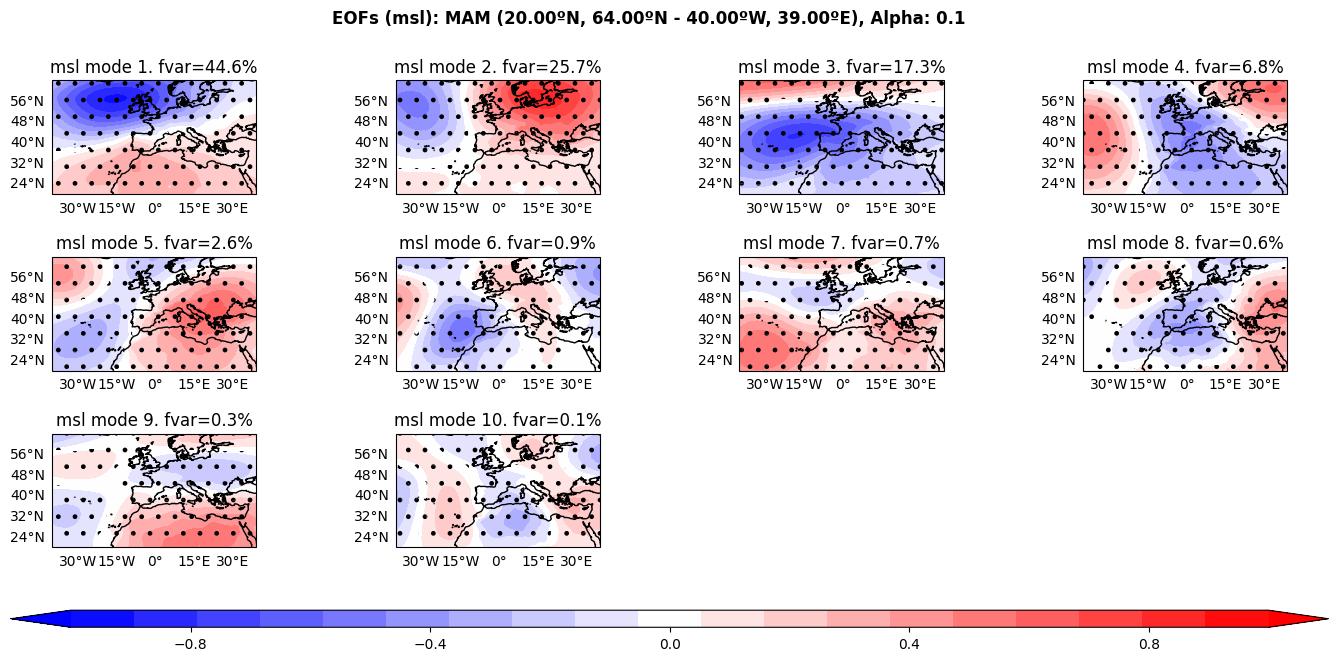

In [15]:
wr.plot_EOFs()

((<Figure size 1600x800 with 3 Axes>, <Figure size 800x800 with 1 Axes>),
 ((<Axes: title={'center': 'msl mode 1. fvar=44.6%'}, xlabel='time'>,
   <Axes: title={'center': 'msl mode 2. fvar=25.7%'}, xlabel='time'>,
   <Axes: title={'center': 'msl mode 3. fvar=17.3%'}, xlabel='time'>),
  (<Axes3D: xlabel='PC1s', ylabel='PC2s', zlabel='PC3s'>,)))

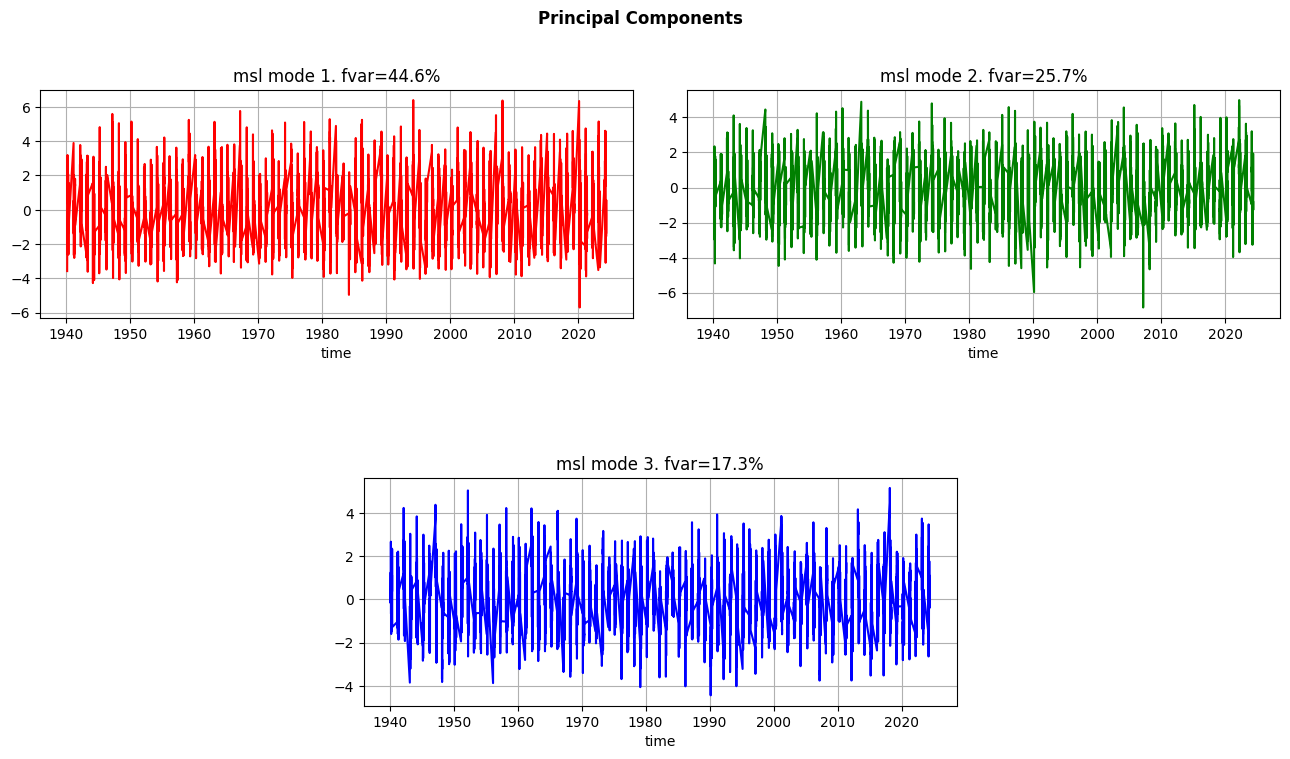

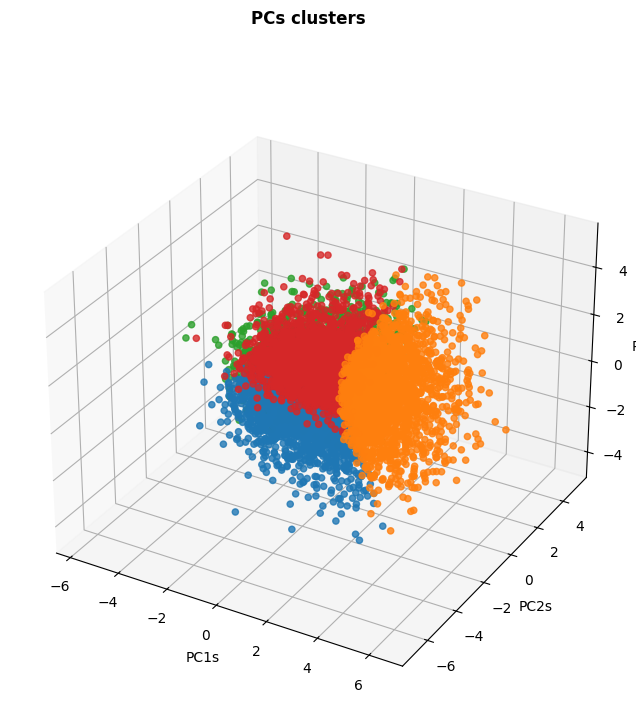

In [16]:
wr.plot_PCs()

# =============================================================================
# WEATHER REGIMES (REGÍMENES DE TIEMPO)



### Para calcular los regímenes meteorológicos necesitamos una serie temporal de referencia para ver cuántos regímenes meteorológicos necesitamos para tener uno que explique la variable de impacto hay que ver cuántos WR se necesitan para explicar la serie temporal


### Elijo un número máximo de cluster, por ejemplo, 10 y un umbral de temperatura o un percentil( por ejemplo, p95). 
### La idea es ver cuantos clusters necesito para explicar ese extremo . 
### Además, elijo un número de iteraciones para repetir el proceso y ver si es robusto. 



# Aqui tenéis que adaptar para que, de vuestro índice, tome un umbral y asi selecciones cuántos clusters hacen falta para poder diferenciar un cluster que lo contenga

In [ ]:
path2='/home/irene/'
pt=xr.open_dataset(path2 +'Spain02_v5.0_DD_010reg_aa3d_pr.nc')
pteste=pt.sel(lat=slice(36.2,43),lon=slice(-2,4))
lonpr=pt.lon; latpr=pt.lat; preci=pteste.pr
preciMAM=preci.groupby('time.season')['MAM']
preciMAMday=np.mean(np.mean(preciMAM,2),1) #este es el indice diario desde 1971 hasta 215
plt.plot(preciMAMday)

In [ ]:
preciMAMday.shape #45 años x 92

In [ ]:
plt.hist(indiceExtremo)

In [ ]:
indiceExtremo=preciMAMday #desde 1971 hasta 2015 45 años
yearslp=np.arange(1940,2025)
iyslp=(yearslp >1970) & (yearslp <2016) #los años que solapan con Extremo


PCs_periodExt=PCs[inslp]  #period for the extreme index 1971_2015 
wtmax = 15; #maximum number of cluster
p95 = np.percentile(indiceExtremo, 95)
thr =p95;
itermax =40;
# Now we fix the number of iterations that we are going to use
#for calculating the probability of rainfall higher than the threshold 
ndd = indiceExtremo[indiceExtremo < thr].size; # to do that, we count the
# number of days with rainfall lower than a threshold
prob = ndd / indiceExtremo.size; # dividing ndd by the total number of days
# we have the probability

#we calculate the information criteria following the paper of Morón et al
IC=ma.empty([itermax,wtmax])
for it in range(itermax): # we test with different iterations
    for Nwt in range(wtmax): # we test with different number of clusters
        IC[it,Nwt]=0
        for k in range(Nwt):
            centroides,indexic = cluster.vq.kmeans2(PCs_periodExt, k+1)      
            # we calculate the IC
            nk = np.array(np.where(indexic==k)).shape[1] # number of days with cluster k
            ndk = np.array(np.where((indexic== k) & (indiceExtremo> thr))).shape[1];
            IC[it,Nwt] =  IC[it,Nwt] + abs(ndk - prob * nk); #contribution to the  IC
            
IC.mean(axis=1).shape

fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Information Criteria',fontsize=16,weight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('IC')
ax.scatter(range(1,wtmax+1),np.nanmean(np.array(IC),0),linewidth= 4,color='green')
ax.grid()



In [ ]:

## As we do different iterations we can see how robust is the information criterio
# including each cluster by calculating the standard deviation
fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Information Criteria',fontsize=16,weight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('IC')
ax.scatter(range(1,wtmax+1),np.nanstd(np.array(IC),0),linewidth= 4,color='green')
ax.grid()




### Una vez analizada la figura anterior, que es crucial, 
### decidimos el número de cluster a considerar


In [ ]:
k=4
# For example, we decide that 5...
centroides, index = cluster.vq.kmeans2((PCs ),k)

#ahora representamos las PCs con los centroides
fig,ax = plt.subplots()
ax = plt.subplot(1,1,1, projection='3d')
ax.set_xlabel('PC1s')
ax.set_ylabel('PC2s')
ax.set_zlabel('PC3s')
ax.grid()
ax.set_title('Scatter Plot PCs cluster')

for nk in range(k):  
    ax.scatter3D(PCs[index==nk,0],PCs [index==nk,1],PCs [index==nk,2])
    
    

In [ ]:
len(index)/dy

In [ ]:
index

## Cálculo de los mapas, como multiplicación de los centroides (coordenadas de PC1, PC2 y PC3) por los EOF (como mapa de regresión Reg)
#ES COMO UNA RECONSTRUCCIÓN
cluster=centroids*Reg
CENTROIDS 4, 10
REG     10, ns

In [ ]:
clusters=np.dot(centroides,REG)
clusters.shape


# =============================================================================
# DIBUJAR CLUSTER i-ésimo (en realidad son las EOFs as reg)
# =============================================================================

## también podemos calcular el valor medio del índice para cada cluster 

### 1. Probabilidad de mi indice por encima de un percentil  en cada CLUSTER

In [ ]:
#index contiene todos los años desde 1940-2023 pero solo necesito 1971-2015
indiceExtremo=preciMAMday
p95 = np.percentile(indiceExtremo, 95)

yearslp=np.arange(1940,2025)
iyslp=(yearslp >1970) & (yearslp <2016) #los años que solapan con Extremo
index2=index.reshape(85,92)
index_PeriodExt=index2[iyslp,:].reshape([45*92])
index_PeriodExt.shape
pWR=np.empty([4,1])
for i in range(4):
    pWR[i]=indiceExtremo[(index_PeriodExt==i) & (indiceExtremo>= p95)].size/(indiceExtremo[index_PeriodExt==i].size)
        

In [ ]:
pWR, p95

pWR

### 2.  Total de mi indice para cada cluster


In [ ]:
#here we calculate the total rainfall per day
TRWR1=indiceExtremo[index_PeriodExt==0].sum()/(indiceExtremo[index_PeriodExt==0].size)
TRWR2=indiceExtremo[index_PeriodExt==1].sum()/(indiceExtremo[index_PeriodExt==1].size)
TRWR3=indiceExtremo[index_PeriodExt==2].sum()/(indiceExtremo[index_PeriodExt==2].size)
TRWR4=indiceExtremo[index_PeriodExt==3].sum()/(indiceExtremo[index_PeriodExt==3].size)


###  3. frecuencia de que aparezca mi indice en cada  WR

In [ ]:
FRWR1=indiceExtremo[index_PeriodExt==0].size/indiceExtremo.size*100
FRWR2=indiceExtremo[index_PeriodExt==1].size/indiceExtremo.size*100
FRWR3=indiceExtremo[index_PeriodExt==2].size/indiceExtremo.size*100
FRWR4=indiceExtremo[index_PeriodExt==3].size/indiceExtremo.size*100


# ahora los dibujamos

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,clusters[0,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20.1,1), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
ax.set_title('SLP Cluster 1 total rain= '+ str(f'{TRWR1:7.2f}')+'mm/day '+'frequency '+str(f'{FRWR1:7.2f}')+'%',fontsize=18,weight='bold')

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,clusters[1,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
ax.set_title('SLP Cluster 2 total rain= '+ str(f'{TRWR2:7.2f}')+'mm/day '+'frequency '+str(f'{FRWR2:7.2f}')+'%',fontsize=18,weight='bold')

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,clusters[2,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20.1,1), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
ax.set_title('SLP Cluster 3 total rain= '+ str(f'{TRWR3:7.2f}')+'mm/day '+'frequency '+str(f'{FRWR3:7.2f}')+'%',fontsize=18,weight='bold')

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,clusters[3,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20.1,1), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
ax.set_title('SLP Cluster 4 total rain= '+ str(f'{TRWR4:7.2f}')+'mm/day '+'frequency '+str(f'{FRWR4:7.2f}')+'%',fontsize=18,weight='bold')



In [ ]:
#de la misma forma podemos crear los cluster a partir de index, haciendo un compuesto de los días que caén en ese cluster
COMP=np.zeros([4,ns])
FREQI=np.zeros(4) #FRECUENCIA DEL INDICE EN SI
for i in range(4):
    nindex=np.sum(index==i) #numero de dias que están en el cluster i
    Maskind=index==i #mascara de los días que están en el cluster i
    COMP[i,:]=np.sum(Mata[Maskind,:],axis=0)/nindex
    FREQI[i]=100*nindex/len(index)

In [ ]:
#Pruebo a pintar el compuesto
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,COMP[0,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20.1,1), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
ax.set_title('SLP Cluster 4 COMPUESTO, frequency '+str(f'{FREQI[0]:7.2f}')+'%',fontsize=18,weight='bold')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top

# Interanual variability

In [ ]:
## ahora, para cada año, vas viendo la frecuencia de tu cluster
nyr=84
wr1= ma.empty([nyr,])
wr2= ma.empty([nyr,])
wr3= ma.empty([nyr,])
wr4= ma.empty([nyr,])


k=0

# each year contains  ndy days
for i in range(nyr):
    wr1[i] = sum(index[k:k+dy] == 0) #sumo todos los valores del índice
    wr2[i] = sum(index[k:k+dy] == 1) 
    wr3[i] = sum(index[k:k+dy] == 2)
    wr4[i] = sum(index[k:k+dy] == 3)
   
    k=k+dy



In [ ]:

# Ploteamos las frecuencias
fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 1 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr1-wr1.mean(),linewidth= 1,color='green', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 2 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr2-wr2.mean(),linewidth= 1,color='orange', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 3 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr3-wr3.mean(),linewidth= 1,color='purple', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 4 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr4-wr4.mean(),linewidth= 1,color='blue', edgecolor = 'k')
ax.grid()